# Diabetes Risk Assessment: Exploratory Data Analysis & Cleaning

## 1. Project Overview & Setup
This project analyzes clinical, lifestyle, and demographic factors associated with diabetes risk.
The goal is to identify key drivers and prepare data for predictive modeling.

In [35]:
%pip install numpy pandas matplotlib seaborn


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting settings
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [37]:
# Load the dataset
df = pd.read_csv('../data/diabetes_risk.csv')

# Verify the shape and preview first 5 rows
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")
df.head()

Dataset Dimensions: 15000 rows, 19 columns



,patient_id,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,1,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,2,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,3,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,4,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,5,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low


In [38]:
# Detailed summary of columns, datatypes, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   patient_id                15000 non-null  int64  
 1   age                       15000 non-null  int64  
 2   gender                    15000 non-null  str    
 3   city                      15000 non-null  str    
 4   bmi                       15000 non-null  float64
 5   family_history_diabetes   15000 non-null  str    
 6   physical_activity_level   15000 non-null  str    
 7   diet_type                 15000 non-null  str    
 8   smoking_status            14528 non-null  str    
 9   alcohol_consumption       11212 non-null  str    
 10  hours_sleep_per_night     15000 non-null  float64
 11  stress_level              15000 non-null  int64  
 12  fasting_blood_sugar       15000 non-null  int64  
 13  hba1c_level               15000 non-null  float64
 14  blood_pressure_sy

In [39]:
# Identify missing values per column
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_pct.round(2)
})

# Display only columns that have missing data
missing_summary[missing_summary['Missing Count'] > 0]

,Missing Count,Percentage (%)
smoking_status,472,3.15
alcohol_consumption,3788,25.25
income_bracket,463,3.09


In [40]:
# Statistical summary for all numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
patient_id,15000.0,7500.500000,4330.271354,1.0,3750.75,7500.5,11250.25,15000.0
age,15000.0,44.333667,10.383753,18.0,38.00,45.0,52.00,80.0
bmi,15000.0,23.062260,4.046391,15.0,20.10,22.7,25.60,40.8
hours_sleep_per_night,15000.0,7.309860,1.109372,3.0,6.70,7.0,8.00,12.0
stress_level,15000.0,5.941200,2.148406,1.0,4.00,6.0,7.00,10.0
fasting_blood_sugar,15000.0,168.789933,38.365822,72.0,145.00,165.0,189.00,400.0
hba1c_level,15000.0,6.878387,0.843276,4.8,6.30,6.8,7.30,13.4
blood_pressure_systolic,15000.0,139.496200,12.660785,80.0,130.00,140.0,150.00,200.0
blood_pressure_diastolic,15000.0,86.256933,8.386529,50.0,80.00,88.0,90.00,120.0
waist_circumference_cm,15000.0,100.207933,10.760331,73.2,92.50,99.3,106.90,148.2


## 2. Data Cleaning and Preprocessing
In this section, we handle redundant columns, address missing values in lifestyle and socioeconomic features, and inspect the target variable (`diabetes_risk`).

In [41]:
# Drop 'patient_id' as it does not carry predictive value
if 'patient_id' in df.columns:
    df.drop(columns=['patient_id'], inplace=True)

print(f"Remaining columns: {df.shape[1]}")

Remaining columns: 18


In [42]:
# Impute missing values with 'Unknown' category
categorical_missing_cols = ['smoking_status', 'alcohol_consumption', 'income_bracket']

for col in categorical_missing_cols:
    df[col] = df[col].fillna('Unknown')

# Verify that no missing values remain
print("Total missing values across the entire dataset:", df.isnull().sum().sum())

Total missing values across the entire dataset: 0


In [43]:
# Check class distribution of the target variable
target_counts = df['diabetes_risk'].value_counts()
target_percent = df['diabetes_risk'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Patient Count': target_counts,
    'Percentage (%)': target_percent.round(2)
})

target_summary

,Patient Count,Percentage (%)
diabetes_risk,,
Low,9000,60.0
Moderate,3750,25.0
High,2250,15.0


/var/folders/2z/bvj3d2ws35z5fvpqzjh51v680000gn/T/ipykernel_10937/3151455682.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='diabetes_risk', order=order, palette='crest')


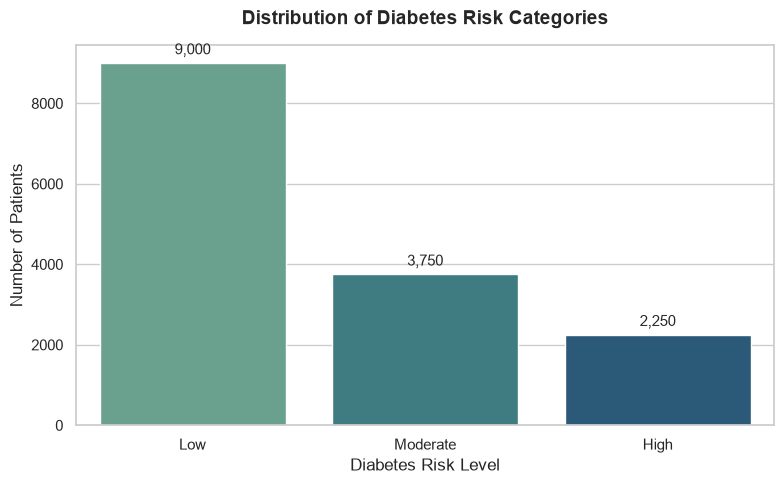

In [44]:
# Visualize target distribution
plt.figure(figsize=(8, 5))
order = ['Low', 'Moderate', 'High']

ax = sns.countplot(data=df, x='diabetes_risk', order=order, palette='crest')
plt.title('Distribution of Diabetes Risk Categories', fontsize=14, weight='bold', pad=15)
plt.xlabel('Diabetes Risk Level', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)

# Add data labels on top of each bar
for p in ax.patches:
    height = int(p.get_height())
    ax.annotate(f'{height:,}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='bottom', fontsize=11, xytext=(0, 4), 
                textcoords='offset points')

plt.tight_layout()
plt.show()

## 3. Exploratory Data Analysis (EDA)

### 3.1. Clinical Biomarkers vs. Diabetes Risk
In this subsection, we examine the behavior of core glycemic markers (`fasting_blood_sugar` and `hba1c_level`) across risk categories.

In [45]:
# Group by risk level and compute central tendencies for glycemic markers
biomarker_stats = df.groupby('diabetes_risk')[['fasting_blood_sugar', 'hba1c_level', 'bmi', 'waist_circumference_cm']].agg(['mean', 'median']).loc[order]
biomarker_stats.round(2)

fasting_blood_sugar        hba1c_level           bmi         \
                             mean median        mean median   mean median   
diabetes_risk                                                               
Low                        148.30  150.0        6.43    6.5  22.13   21.8   
Moderate                   183.32  182.0        7.20    7.2  24.06   23.8   
High                       226.54  220.0        8.14    8.0  25.11   24.8   

              waist_circumference_cm         
                                mean median  
diabetes_risk                                
Low                            97.92   97.2  
Moderate                      102.68  102.0  
High                          105.25  104.5

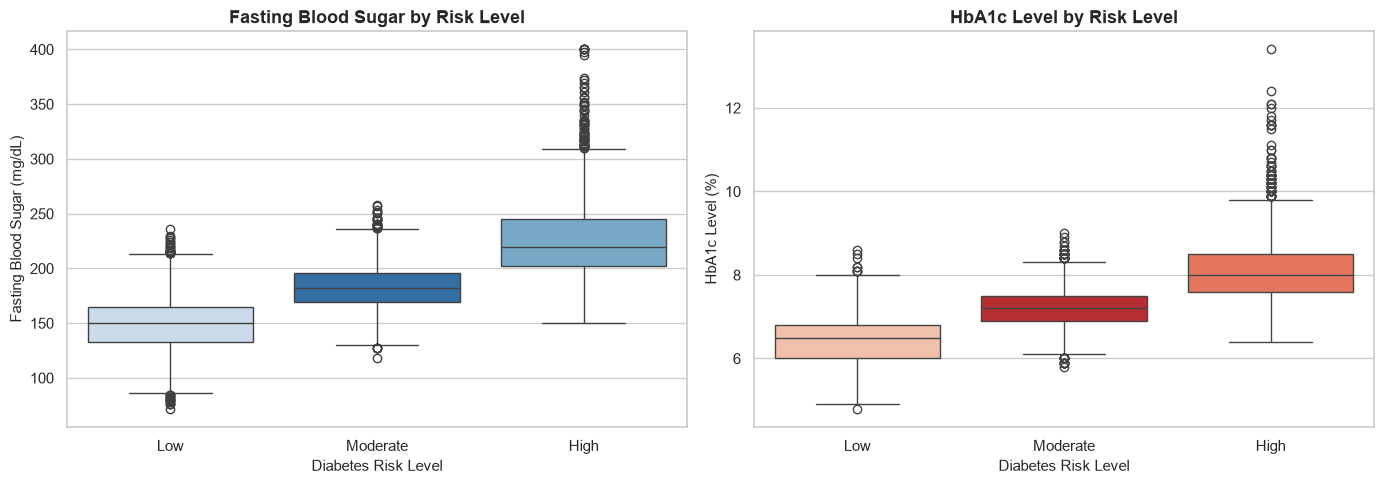

In [46]:
# Plot side-by-side boxplots for Fasting Blood Sugar and HbA1c
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Fasting Blood Sugar
sns.boxplot(
    data=df, 
    x='diabetes_risk', 
    y='fasting_blood_sugar', 
    order=order, 
    hue='diabetes_risk',
    palette='Blues', 
    legend=False,
    ax=axes[0]
)
axes[0].set_title('Fasting Blood Sugar by Risk Level', fontsize=13, weight='bold')
axes[0].set_xlabel('Diabetes Risk Level', fontsize=11)
axes[0].set_ylabel('Fasting Blood Sugar (mg/dL)', fontsize=11)

# 2. HbA1c Level
sns.boxplot(
    data=df, 
    x='diabetes_risk', 
    y='hba1c_level', 
    order=order, 
    hue='diabetes_risk',
    palette='Reds', 
    legend=False,
    ax=axes[1]
)
axes[1].set_title('HbA1c Level by Risk Level', fontsize=13, weight='bold')
axes[1].set_xlabel('Diabetes Risk Level', fontsize=11)
axes[1].set_ylabel('HbA1c Level (%)', fontsize=11)

plt.tight_layout()
plt.show()

**Key Takeaways from Biomarker Analysis:**
* Patients in the **High** risk tier exhibit substantially elevated fasting blood sugar and HbA1c levels compared to the **Low** and **Moderate** cohorts.
* There is a clear progressive trend: higher biomarker levels strongly align with higher assigned risk categories.

### 3.2. Lifestyle, Behavioral Factors & Target Distribution
In this subsection, we investigate how lifestyle choices (physical activity, diet, sleep duration, and stress levels) correlate with diabetes risk categories.

In [47]:
# Cross-tabulation: Physical activity level vs Diabetes risk (in percentage)
activity_crosstab = pd.crosstab(
    df['physical_activity_level'], 
    df['diabetes_risk'], 
    normalize='index' # Calculate percentages along rows (so each row sums to 100%)
)[order] * 100

activity_crosstab.round(2)

diabetes_risk,Low,Moderate,High
physical_activity_level,,,
Active,70.12,20.10,9.78
Moderate,59.09,26.55,14.36
Sedentary,50.48,28.51,21.01


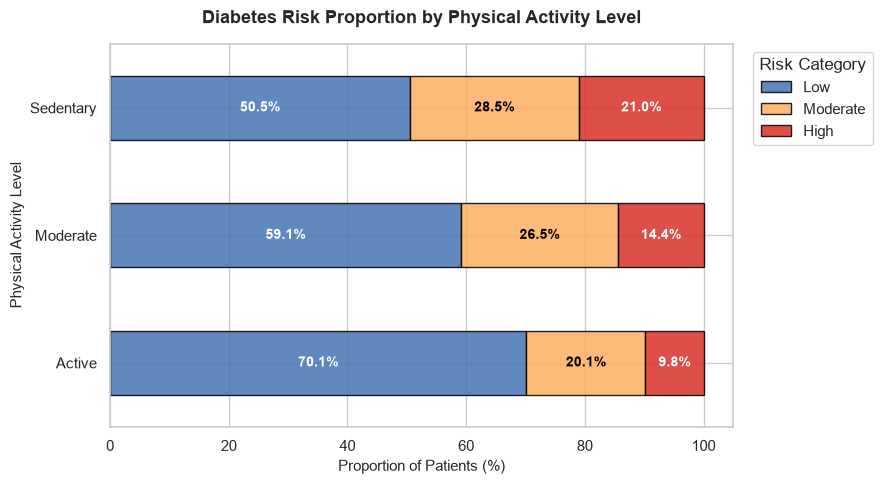

In [48]:
# Visualizing risk proportion across physical activity levels
fig, ax = plt.subplots(figsize=(9, 5))

# Plot 100% stacked horizontal bar chart
activity_crosstab.plot(
    kind='barh', 
    stacked=True, 
    color=['#4575b4', '#fdae61', '#d73027'], # Cool blue to warning red palette
    edgecolor='black',
    alpha=0.85,
    ax=ax
)

plt.title('Diabetes Risk Proportion by Physical Activity Level', fontsize=13, weight='bold', pad=15)
plt.xlabel('Proportion of Patients (%)', fontsize=11)
plt.ylabel('Physical Activity Level', fontsize=11)
plt.legend(title='Risk Category', bbox_to_anchor=(1.02, 1), loc='upper left')

# Add percentage text inside each segment
for n, c in enumerate(activity_crosstab.columns):
    for i, val in enumerate(activity_crosstab[c]):
        cum_sum = activity_crosstab.iloc[i, :n].sum()
        ax.text(cum_sum + val / 2, i, f'{val:.1f}%', 
                ha='center', va='center', color='white' if c in ['Low', 'High'] else 'black', 
                weight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [49]:
# Compute median sleep and stress per risk level
lifestyle_summary = df.groupby('diabetes_risk')[['hours_sleep_per_night', 'stress_level']].agg(['mean', 'median']).loc[order]
lifestyle_summary.round(2)

hours_sleep_per_night        stress_level       
                               mean median         mean median
diabetes_risk                                                 
Low                            7.35    7.0         5.76    6.0
Moderate                       7.27    7.0         6.18    6.0
High                           7.23    7.0         6.27    6.0

### 3.3. Correlation Matrix & Feature Interdependencies
To evaluate linear associations, we map the ordinal target (`diabetes_risk`) to integer ranks (`Low: 0`, `Moderate: 1`, `High: 2`) and compute Pearson/Spearman correlation coefficients.

In [50]:
# Create a temporary numeric mapping of the target for correlation analysis
risk_map = {'Low': 0, 'Moderate': 1, 'High': 2}
df_numeric = df.copy()
df_numeric['diabetes_risk_encoded'] = df_numeric['diabetes_risk'].map(risk_map)

# Select numeric columns for the correlation matrix
numeric_cols = df_numeric.select_dtypes(include=[np.number]).columns
corr_matrix = df_numeric[numeric_cols].corr()

# Check top correlations with the target variable
target_corr = corr_matrix['diabetes_risk_encoded'].sort_values(ascending=False)
print("Correlation of numerical features with Diabetes Risk:")
print(target_corr.round(3))

Correlation of numerical features with Diabetes Risk:
diabetes_risk_encoded       1.000
fasting_blood_sugar         0.738
hba1c_level                 0.734
bmi                         0.289
age                         0.287
waist_circumference_cm      0.268
blood_pressure_systolic     0.212
blood_pressure_diastolic    0.167
stress_level                0.100
hours_sleep_per_night      -0.043
Name: diabetes_risk_encoded, dtype: float64


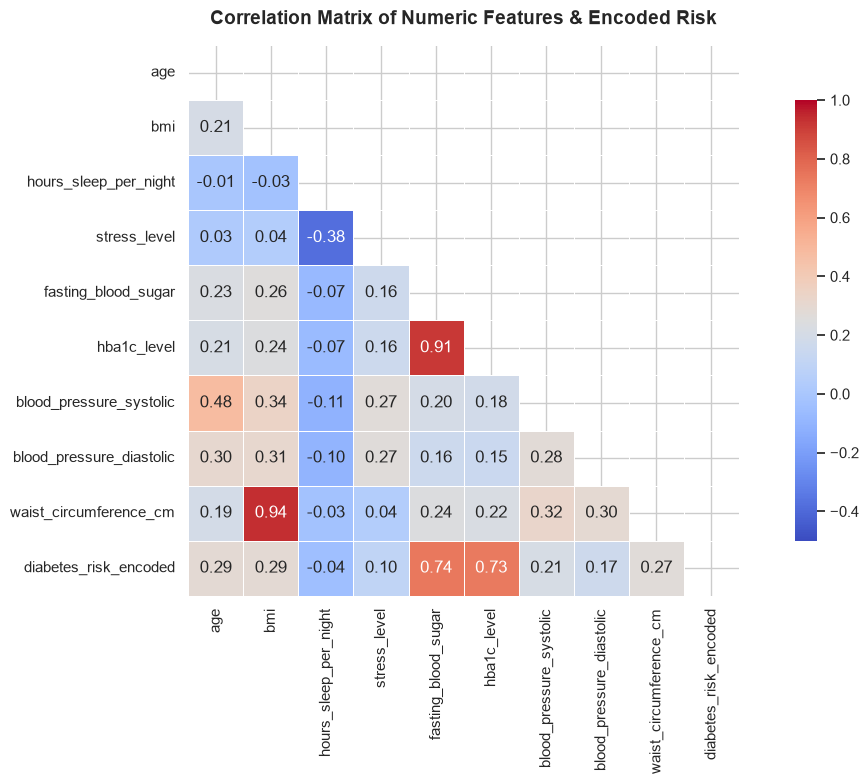

In [51]:
# Plot lower-triangle heatmap for readability
plt.figure(figsize=(12, 8))

# Mask the upper triangle (symmetric duplication)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    vmin=-0.5, vmax=1.0,
    square=True, 
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Matrix of Numeric Features & Encoded Risk', fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.show()

In [52]:
import os

# Create 'images' directory if it doesn't exist
os.makedirs('../images', exist_ok=True)

# Save the heatmap plot for documentation
fig = plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-0.5, vmax=1.0, square=True, linewidths=0.5)
plt.title('Correlation Matrix', fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=300)
plt.close()

print("Heatmap saved to images/correlation_heatmap.png successfully!")

Heatmap saved to images/correlation_heatmap.png successfully!


## 4. Statistical Hypothesis Testing
To confirm that observed differences across risk groups are statistically significant and not artifacts of random sampling, we conduct:
1. **Chi-Square Test of Independence ($\chi^2$)** for categorical lifestyle factors.
2. **Kruskal-Wallis H-Test** (non-parametric ANOVA) for continuous biomarkers.

In [53]:
%pip install scipy scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [54]:
from scipy import stats

# 1. Hypothesis: Physical activity is independent of diabetes risk
chi2_act, p_act, dof_act, _ = stats.chi2_contingency(pd.crosstab(df['physical_activity_level'], df['diabetes_risk']))

# 2. Hypothesis: Family history of diabetes is independent of diabetes risk
chi2_fam, p_fam, dof_fam, _ = stats.chi2_contingency(pd.crosstab(df['family_history_diabetes'], df['diabetes_risk']))

print(f"Physical Activity vs Risk: Chi2 = {chi2_act:.2f}, p-value = {p_act:.4e}")
print(f"Family History vs Risk:   Chi2 = {chi2_fam:.2f}, p-value = {p_fam:.4e}")

Physical Activity vs Risk: Chi2 = 453.49, p-value = 7.6465e-97
Family History vs Risk:   Chi2 = 402.30, p-value = 4.3892e-88


In [55]:
# Separate fasting blood sugar by risk categories
fbs_low = df[df['diabetes_risk'] == 'Low']['fasting_blood_sugar']
fbs_mod = df[df['diabetes_risk'] == 'Moderate']['fasting_blood_sugar']
fbs_high = df[df['diabetes_risk'] == 'High']['fasting_blood_sugar']

# Kruskal-Wallis test for Fasting Blood Sugar
kw_fbs, p_fbs = stats.kruskal(fbs_low, fbs_mod, fbs_high)

# Separate HbA1c by risk categories
hba1c_low = df[df['diabetes_risk'] == 'Low']['hba1c_level']
hba1c_mod = df[df['diabetes_risk'] == 'Moderate']['hba1c_level']
hba1c_high = df[df['diabetes_risk'] == 'High']['hba1c_level']

# Kruskal-Wallis test for HbA1c
kw_hba1c, p_hba1c = stats.kruskal(hba1c_low, hba1c_mod, hba1c_high)

print(f"Fasting Blood Sugar across groups: H-stat = {kw_fbs:.2f}, p-value = {p_fbs:.4e}")
print(f"HbA1c Level across groups:        H-stat = {kw_hba1c:.2f}, p-value = {p_hba1c:.4e}")

Fasting Blood Sugar across groups: H-stat = 8072.75, p-value = 0.0000e+00
HbA1c Level across groups:        H-stat = 7817.12, p-value = 0.0000e+00


### Key Statistical Findings:
1. **Physical Activity vs. Diabetes Risk:** Reject $H_0$ ($p = 7.65 \times 10^{-97} < 0.05$). Physical activity level has a statistically significant association with diabetes risk.
2. **Family History vs. Diabetes Risk:** Reject $H_0$ ($p = 4.39 \times 10^{-88} < 0.05$). Genetic predisposition plays an undeniable role in patient risk categorization.
3. **Glycemic Markers (Fasting Glucose & HbA1c):** Reject $H_0$ ($p \approx 0.0000 < 0.05$, $H > 7800$). Risk tiers are fundamentally separated by glycemic control markers with near-absolute statistical significance.

## 5. Machine Learning Modeling & Feature Importance
We train a **Random Forest Classifier** to assess predictive capability and quantify the relative contribution of each feature to diabetes risk stratification.

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Separate features (X) and target (y)
X = df.drop(columns=['diabetes_risk'])
y = df['diabetes_risk'].map(risk_map)  # 0: Low, 1: Moderate, 2: High

# 2. Convert categorical text columns to numeric dummy variables (One-Hot Encoding)
X_encoded = pd.get_dummies(X, drop_first=True)

# 3. Split into Train (80%) and Test (20%) datasets
# 'stratify=y' ensures the 60/25/15 class balance is preserved in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set:     {X_test.shape[0]} samples")
print(f"Total features after encoding: {X_encoded.shape[1]}")

Training set: 12000 samples
Test set:     3000 samples
Total features after encoding: 43


In [57]:
# Initialize and train Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,      # 100 decision trees
    max_depth=12,          # Limit tree depth to prevent overfitting
    random_state=42, 
    n_jobs=-1              # Use all CPU cores on your Mac
)

rf_model.fit(X_train, y_train)

# Predict on test data
y_pred = rf_model.predict(X_test)

# Display classification metrics
target_names = ['Low', 'Moderate', 'High']
print("Model Performance Report:\n")
print(classification_report(y_test, y_pred, target_names=target_names))

Model Performance Report:

              precision    recall  f1-score   support

         Low       0.85      0.91      0.88      1800
    Moderate       0.58      0.55      0.56       750
        High       0.83      0.68      0.74       450

    accuracy                           0.78      3000
   macro avg       0.75      0.71      0.73      3000
weighted avg       0.78      0.78      0.78      3000



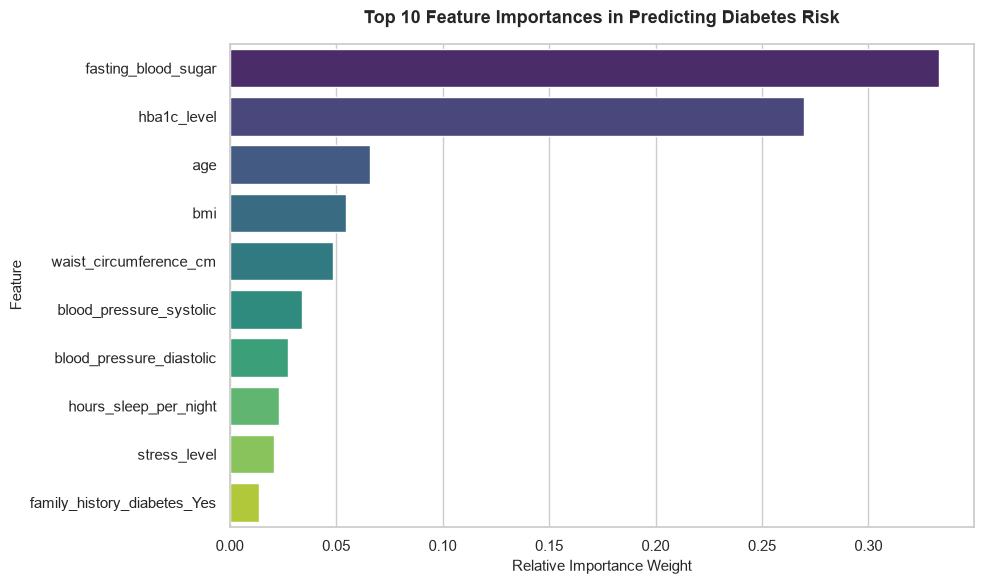

,Feature,Importance
0,fasting_blood_sugar,0.332937
1,hba1c_level,0.269780
2,age,0.065911
3,bmi,0.054430
4,waist_circumference_cm,0.048612
5,blood_pressure_systolic,0.034107
6,blood_pressure_diastolic,0.027375
7,hours_sleep_per_night,0.022941
8,stress_level,0.020887
9,family_history_diabetes_Yes,0.013602


In [58]:
# Extract feature importance values
feature_importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot top 10 most influential features
plt.figure(figsize=(10, 6))
top_10 = feature_importance.head(10)

sns.barplot(
    data=top_10, 
    x='Importance', 
    y='Feature', 
    hue='Feature',
    palette='viridis', 
    legend=False
)
plt.title('Top 10 Feature Importances in Predicting Diabetes Risk', fontsize=13, weight='bold', pad=15)
plt.xlabel('Relative Importance Weight', fontsize=11)
plt.ylabel('Feature', fontsize=11)

# Save chart for README
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=300)
plt.show()

# Display top 10 as a table
top_10.reset_index(drop=True)

## 6. Executive Summary & Clinical Conclusions
1. **Primary Diagnostic Drivers:** Fasting blood sugar (33.3%) and HbA1c (27.0%) account for over 60% of the predictive importance in classifying diabetes risk tiers.
2. **Behavioral Impact:** Physical activity is the most significant modifiable factor. Sedentary individuals exhibit a high-risk rate of **21.0%**, compared to only **9.8%** among active individuals (a **2.15x** relative increase).
3. **Model Efficacy:** The baseline Random Forest Classifier achieved **78% overall accuracy** on unseen test data across 3 ordinal risk categories (`Low`, `Moderate`, `High`).
4. **Adiposity Measures:** BMI and waist circumference demonstrate strong multicollinearity ($r = 0.94$), confirming that either metric reliably captures metabolic excess adiposity.

In [59]:
import os

# Create 'images' in the project root
os.makedirs('../images', exist_ok=True)

# Re-save Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', vmin=-0.5, vmax=1.0, square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features & Encoded Risk', fontsize=14, weight='bold', pad=15)
plt.tight_layout()
plt.savefig('../images/correlation_heatmap.png', dpi=300)
plt.close()

# Re-save Feature Importance Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_10, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Feature Importances in Predicting Diabetes Risk', fontsize=13, weight='bold', pad=15)
plt.xlabel('Relative Importance Weight', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.savefig('../images/feature_importance.png', dpi=300)
plt.close()

print("Both charts successfully saved to images/ folder!")

Both charts successfully saved to images/ folder!
